In [1]:
# 26 05 21

### 컨벌루션 및 맥스풀링

In [2]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, t_train), (x_test, t_test) = mnist.load_data()

In [3]:
x_train.shape, t_train.shape, x_test.shape, t_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
# 이미지 하나 출력

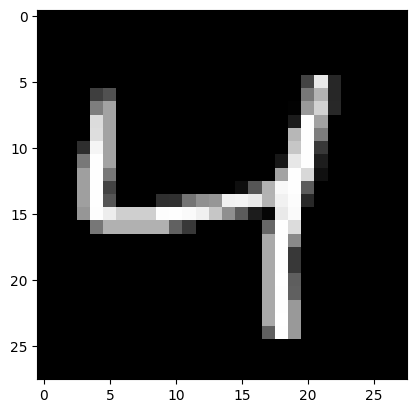

In [5]:
plt.imshow(x_train[2], cmap='gray')

In [6]:
import numpy as np

horizontal_filter = np.array([[1., 1., 1.],
                             [0., 0., 0.], 
                             [-1., -1., -1.]])
vertical_filter = np.array([[1., 0., -1.],
                           [1., 0., -1.],
                           [1., 0., -1.]])

In [7]:
test_image = x_train[2]
original_image_size = test_image.shape[0]   # test_image.shape : (28, 28)
print("original_image_size = ", original_image_size)
conv_output_size = int((original_image_size - 3)/1 + 1)
print("output size = ", conv_output_size)

original_image_size =  28
output size =  26


In [8]:
filter_size = 3 

def get_conv_image(filter):
    filtered_image = np.zeros((conv_output_size, conv_output_size))
    for i in range(conv_output_size):
        for j in range(conv_output_size):
            indice_image = test_image[i:(i + filter_size), j:(j + filter_size)] * filter
            indice_sum = np.sum(indice_image)
            if (indice_sum > 255):
                indice_sum = 255

            filtered_image[i, j] = indice_sum

    return filtered_image

In [9]:
vertical_filtered_image = get_conv_image(vertical_filter)
horizontal_filtered_image = get_conv_image(horizontal_filter)

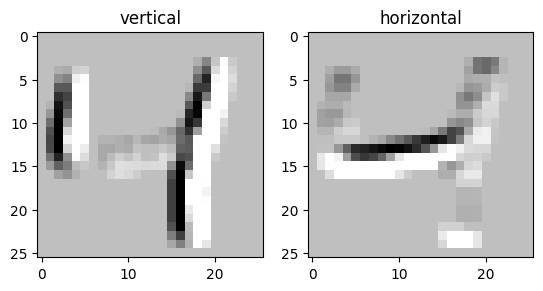

In [10]:
plt.subplot(1, 2, 1)
plt.title('vertical')
plt.imshow(vertical_filtered_image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('horizontal')
plt.imshow(horizontal_filtered_image, cmap='gray')
plt.show()

In [11]:
sobel_image = np.sqrt(np.square(horizontal_filtered_image) + np.square(vertical_filtered_image))

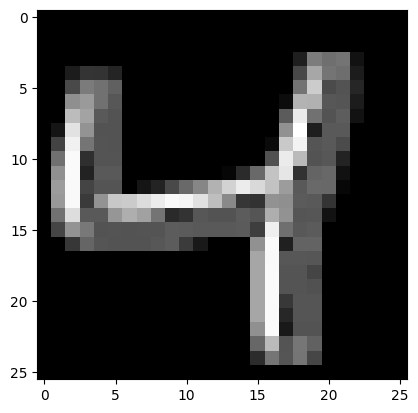

In [12]:
plt.imshow(sobel_image, cmap='gray')

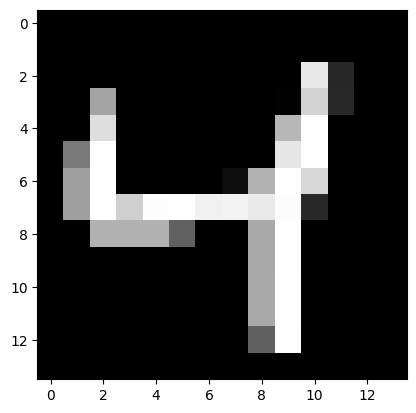

In [13]:
import numpy as np

image = x_train[2]
image_x = image.shape[0]
image_y = image.shape[1]

new_image_x = int(image_x / 2)
new_image_y = int(image_y / 2)

pooled_image = np.zeros((new_image_x, new_image_y))
for x in range(0, image_x, 2):    # 여기서 쿨링 연산
    for y in range(0, image_y, 2):
        pooled_image[int(x/2), int(y/2)] = np.max(image[x:x + 2, y:y + 2])

plt.imshow(pooled_image, cmap='gray')

### Mnist 데이터 분류

In [14]:
# 이제 분론 들어갈 거임 (실습!)

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [16]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [17]:
x_train, x_test = x_train / 255.0, x_test / 255.0

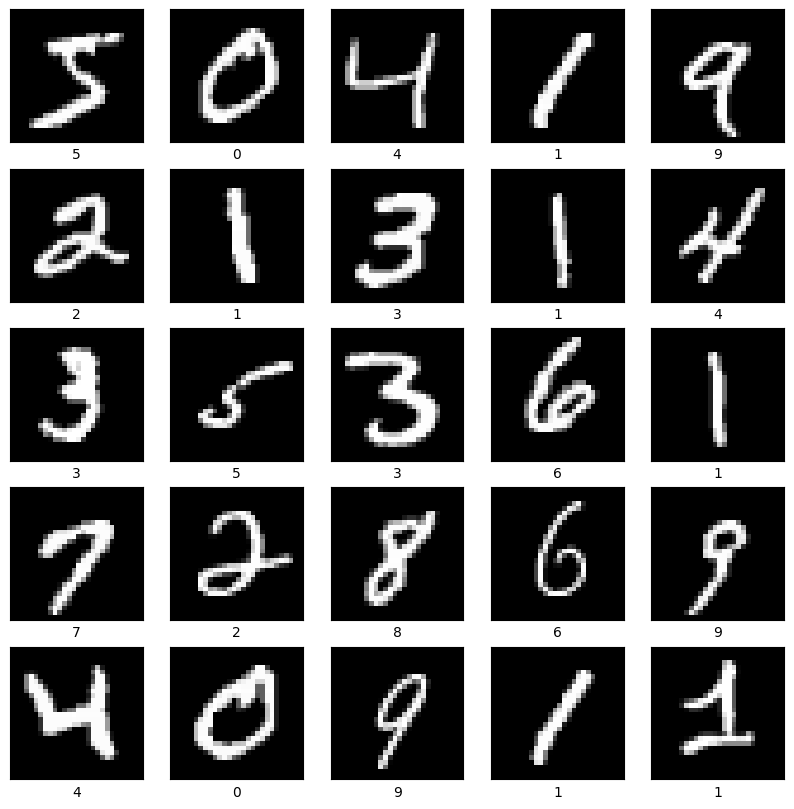

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for index in range(25):
    plt.subplot(5, 5, index+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[index], cmap='gray')
    plt.xlabel(str(y_train[index]))
plt.show()

In [19]:
# 모델설계

In [20]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((28, 28, 1)),              # 컨볼루션 연산
    tf.keras.layers.Conv2D(16, 3, activation='relu'),  # 2차원으로 연산
    tf.keras.layers.Flatten(), # 입력층
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#### Conv2D(16, 3 or (3,3), padding='valid', input_shape=(28, 28, 1), activation='relu')
- 첫번째 인자 : 컨볼루션 필터의 수
- 두번째 인자 : 컨볼루션 커널의 (행, 열) 크기
- padding : 경계 처리 방법 정의.
    - 'valid' : 유효한 영역만 출력.출력 이미지 사이즈는 입력 사이즈보다 작아진다.
    - 'same' : 출력 이미지 사이즈가 입력 이미지 사이즈와 동일하다.
- input_shape : 샘플 수를 제외한 입력 형태 정의. 모델에서 첫 레이어일 때만 정의한다.
    - (행, 열, 채널 수)로 정의한다. 흑백영상인 경우에는 채널이 1이고, 컬러(RGB)영상인 경우에는 채널을 3으로 설정한다.
- activation : 활성화 함수를 설정한다.
    - 'linear' : 입력뉴런과 가중치로 계산된 결과값이 그대로 출력으로 나온다.default=None
    - 'relu' : rectifier 함수, 은익층에 주로 쓰인다.
    - 'sigmoid' : 시그모이드 함수, 이진 분류 문제에서 출력층에 주로 쓰인다.
    - 'softmax' : 소프트맥스 함수, 다중 클래스 분류 문제에서 출력층에 주로 쓰인다.

In [21]:
# 학습

In [22]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5


1875/1875 [==============================] - 21s 10ms/step - loss: 0.1505 - accuracy: 0.9549
Epoch 2/5
1875/1875 [==============================] - 18s 10ms/step - loss: 0.0525 - accuracy: 0.9838
Epoch 3/5
1875/1875 [==============================] - 19s 10ms/step - loss: 0.0303 - accuracy: 0.9897
Epoch 4/5
1875/1875 [==============================] - 18s 10ms/step - loss: 0.0191 - accuracy: 0.9938
Epoch 5/5
1875/1875 [==============================] - 19s 10ms/step - loss: 0.0128 - accuracy: 0.9959


In [23]:
model.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - loss: 0.0613 - accuracy: 0.9834 - 1s/epoch - 4ms/step


[0.061347924172878265, 0.9833999872207642]

In [24]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 28, 28, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 26, 26, 16)        160       
                                                                 
 flatten (Flatten)           (None, 10816)             0         
                                                                 
 dense (Dense)               (None, 128)               1384576   
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1386026 (5.29 MB)
Trainable params: 1386026 (5.29 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Keras API(Sequential vs Functional)

Tensorflow에서 keras api를 활용하는 방법이 크게 두가지.

- Sequential은 layer의 구조가 순차적으로 있을때 사용이 편리.
- Functional API를 활용한다면 복잡한 구조를 설계할 수 있음.
    - 예를 들어서 input, output을 여러개 관리 하거나, layer 사이사이에 연결을 해줄 때.

In [25]:
inputs = keras.Input(shape=(28, 28))
x = layers.Reshape((28, 28, 1))(inputs)
x = layers.Conv2D(16, 3, activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(128)(x)
x = layers.Dense(10, activation='softmax')(x)
outputs = x

model = keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 reshape_1 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 conv2d_1 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 flatten_1 (Flatten)         (None, 10816)             0         
                                                                 
 dense_2 (Dense)             (None, 128)               1384576   
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1386026 (5.29 MB)
Trainable params: 1386026 (5.

In [26]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [27]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test, verbose=0)

Epoch 1/5
1875/1875 [==============================] - 16s 8ms/step - loss: 0.1510 - accuracy: 0.9547
Epoch 2/5
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0679 - accuracy: 0.9787
Epoch 3/5
1875/1875 [==============================] - 13s 7ms/step - loss: 0.0478 - accuracy: 0.9850
Epoch 4/5
1875/1875 [==============================] - 13s 7ms/step - loss: 0.0356 - accuracy: 0.9889
Epoch 5/5
1875/1875 [==============================] - 13s 7ms/step - loss: 0.0271 - accuracy: 0.9908


[0.07772069424390793, 0.9797999858856201]

In [28]:
# 새롭게 모델 설계

In [29]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

In [30]:
x_train = np.reshape(x_train, (60000, 28, 28, 1))
x_test = np.reshape(x_test, (10000, 28, 28, 1))

In [31]:
model = Sequential()
model.add(Conv2D(16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 16)        0         
 D)                                                              
                                                                 
 flatten_2 (Flatten)         (None, 2704)              0         
                                                                 
 dense_4 (Dense)             (None, 128)               346240    
                                                                 
 dense_5 (Dense)             (None, 10)                1290      
                                                                 
Total params: 347690 (1.33 MB)
Trainable params: 347690 (1.33 MB)
Non-trainable params: 0 (0.00 Byte)
_________________

In [32]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test, verbose=2)

Epoch 1/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.1719 - accuracy: 0.9489
Epoch 2/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0589 - accuracy: 0.9816
Epoch 3/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0374 - accuracy: 0.9884
Epoch 4/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0260 - accuracy: 0.9919
Epoch 5/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0174 - accuracy: 0.9946
313/313 - 1s - loss: 0.0509 - accuracy: 0.9847 - 708ms/epoch - 2ms/step


[0.050919901579618454, 0.9847000241279602]

In [33]:
##

In [34]:
model = Sequential()
model.add(Conv2D(16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(16, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 13, 13, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 11, 11, 16)        2320      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 5, 5, 16)          0         
 g2D)                                                            
                                                                 
 flatten_3 (Flatten)         (None, 400)               0         
                                                                 
 dense_6 (Dense)             (None, 128)              

In [35]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test, verbose=2)

Epoch 1/5
1875/1875 [==============================] - 7s 3ms/step - loss: 0.1612 - accuracy: 0.9516
Epoch 2/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0562 - accuracy: 0.9826
Epoch 3/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0410 - accuracy: 0.9869
Epoch 4/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0300 - accuracy: 0.9906
Epoch 5/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0240 - accuracy: 0.9923
313/313 - 1s - loss: 0.0360 - accuracy: 0.9883 - 511ms/epoch - 2ms/step


[0.03604589402675629, 0.9883000254631042]